# Imports
Imports used for this section

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('../../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
df.shape

(768, 9)

In [12]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [23]:
impossibles = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
impossibles_zero = (df[impossibles] == 0).sum()
impossibles_zero

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

# Dataset Analysis
- **Biometric 0's:** Glucose, BMI, blood pressure, skin thickness and insulin all have minimum values of 0. These are biologically impossible, this is due to missing values in the dataset being recorded as 0 instead of NaN. Pregnancies can be a legitimate 0, as people do not have to be pregnant, but it is relevant as it may be a factor in diabetes.
- **Insulin:** Has a very high zero count, suggesting that the dataset is not properly cleaned, and this column is unreliable for training.


In [24]:
(impossibles_zero/df.shape[0])*100

Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64

In [29]:
(df[impossibles] == 0).any(axis=1).sum()

np.int64(376)

# Options
- Impute missing values with mean, median or mode
- Drop column
- Drop rows

In [32]:
df_impossibles = df[impossibles].copy()

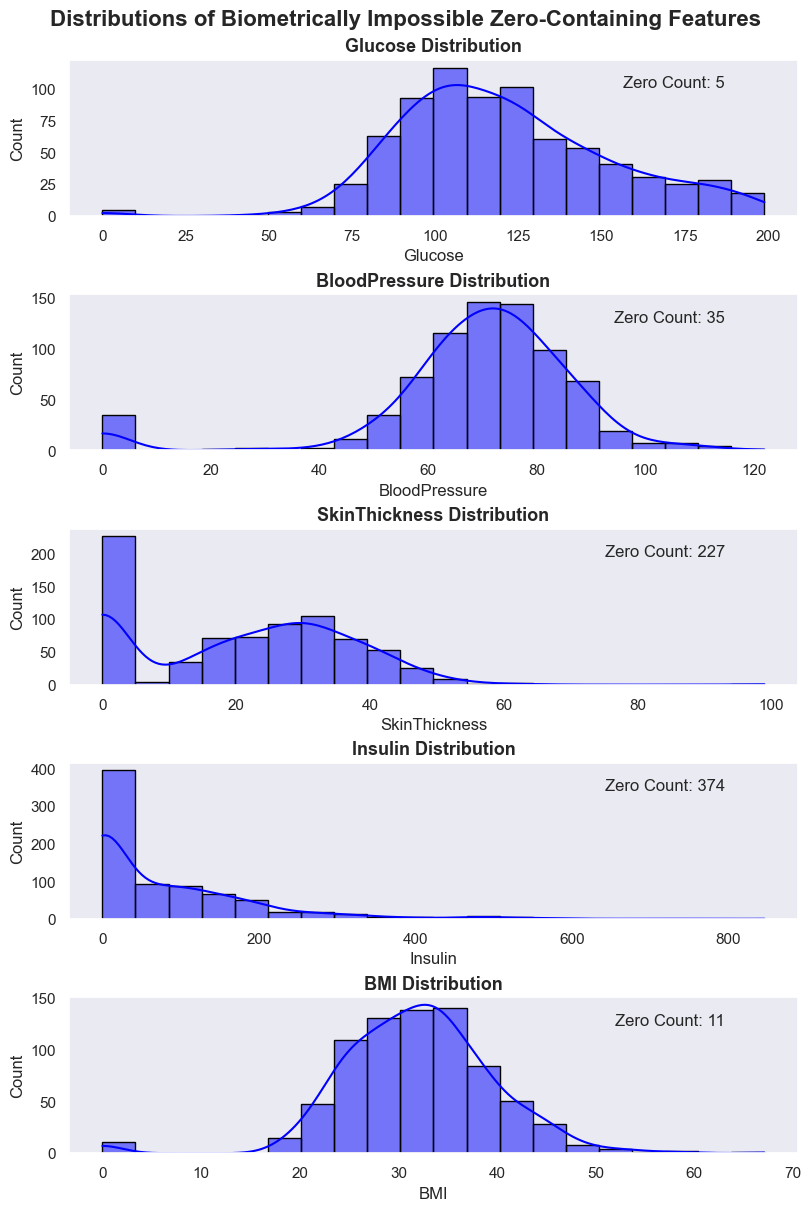

In [56]:
fig, axes = plt.subplots(len(impossibles), 1, figsize=(8, 12), constrained_layout=True)

for ax, col in zip(axes, impossibles):
    zero_count = (df[col] == 0).sum()
    sns.histplot(df[col], bins=20, kde=True, color='blue', edgecolor='black', ax=ax)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.annotate(f'Zero Count: {zero_count}', xy=(0.9, 0.9), xycoords='axes fraction', ha='right', va='top')

plt.suptitle('Distributions of Biometrically Impossible Zero-Containing Features', fontsize=16, fontweight='bold')
plt.show()

# Impossibles Analysis
- Glucose, Blood Pressure and BMI have the most normal distributions from the data set of biologically impossible 0's.
- Distributions of all columns are distorted by 0's, true distribution only visible after replacing values with NaN.

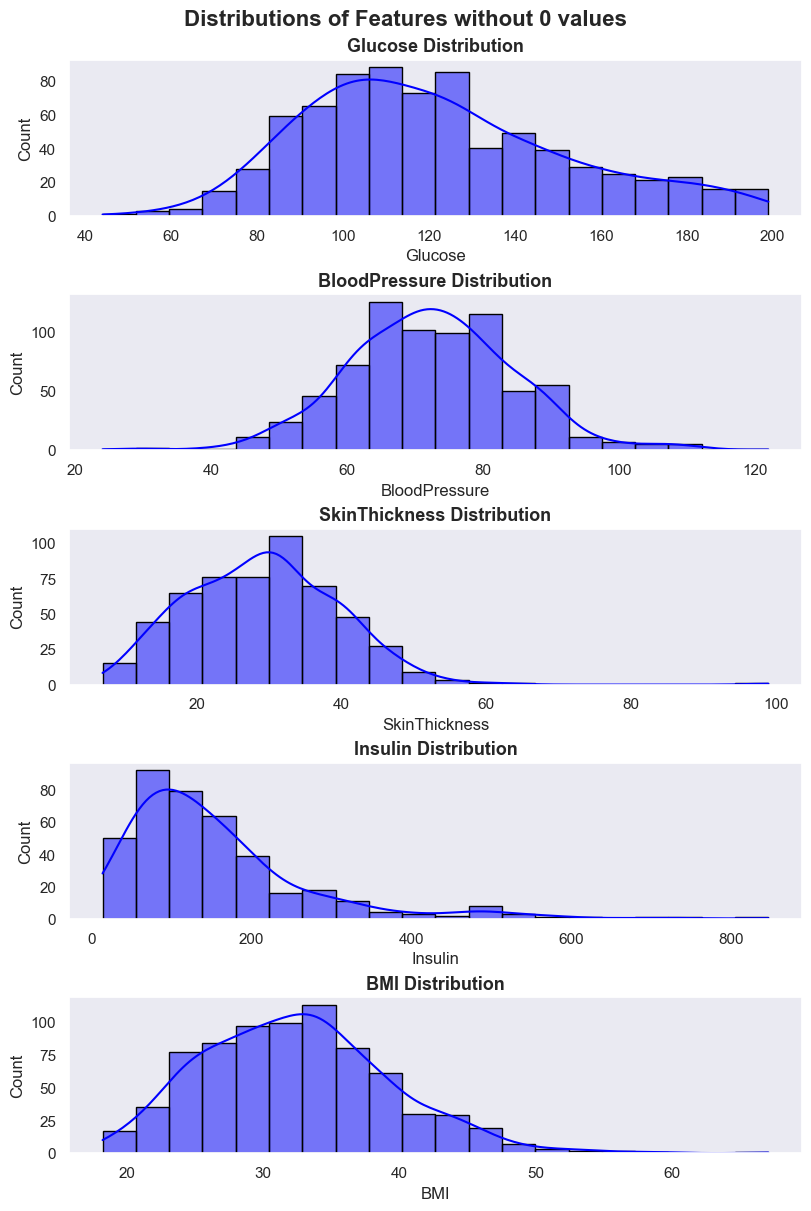

In [57]:
fig, axes = plt.subplots(len(impossibles), 1, figsize=(8, 12), constrained_layout=True)

for ax, col in zip(axes, impossibles):
    sns.histplot(df_impossibles[df_impossibles[col] != 0][col], bins=20, kde=True, color='blue', edgecolor='black', ax=ax)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Distributions of Features without 0 values', fontsize=16, fontweight='bold')
plt.show()

# Histogram Analysis
- **Glucose:** Follows a normal distribution, I can use the mean for imputation.
- **Blood Pressure:** Also follows a normal distribution, I can use the mean for imputation.
- **Skin Thickness:** Is skewed to the right, mean is increased so will use median for imputation.
- **Insulin:** Right skewed, also contains 48% 0's, I will drop this column for training as it will become overfit with imputation.
- **BMI:** Is skewed to the right, mean is increased so will use median for imputation.